# DNV-RP-F110 global-buckling response screening

This example uses NeqSim's edition-aware `DnvRpF110GlobalBucklingResponseScreeningKernel` for the current `DNV-RP-F110 2019-09+AMD:2021-09` basis. It compares results from an external global structural analysis with caller-controlled force, longitudinal-strain, global-displacement, and feed-in limits for named route locations and design situations.

> **Boundary:** this is a regression-backed `SCREENING` calculation, not DNV conformity. It does not calculate effective axial force, critical buckling, buckle initiation/prevention, Hobbs or finite-element response, soil springs, imperfections or triggers, buckle sharing, local capacity, fatigue, or DNV-ST-F101 acceptance. Every response and limit is external evidence and engineering approval remains required. See the [DNV publisher page](https://www.dnv.com/energy/standards-guidelines/dnv-rp-f110-global-buckling-of-submarine-pipelines/).

In [1]:
from pathlib import Path
import os
import sys
import jpype

ROOT = Path.cwd().resolve()
while not (ROOT / 'pom.xml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'pom.xml').exists(), 'Run this notebook from the NeqSim repository tree'

if not jpype.isJVMStarted():
    local_classpath = os.environ.get('NEQSIM_NOTEBOOK_CLASSPATH')
    if local_classpath:
        jpype.startJVM(classpath=local_classpath.split(os.pathsep), convertStrings=True)
    else:
        sys.path.insert(0, str(ROOT / 'devtools'))
        from neqsim_dev_setup import neqsim_init
        neqsim_init(project_root=ROOT, recompile=not (ROOT / 'target/classes').exists(), verbose=False)

from jpype import JClass
import pandas as pd
import matplotlib.pyplot as plt
print('Workspace kernel loaded:', ROOT)

Workspace kernel loaded: /workspace/scratch/de313162ffce/repo_f110


## 1. Verified demonstration basis

The values below are project-controlled demonstration inputs, not F110 equations, limits, or acceptance criteria. In a project, every response would come from a controlled global structural model and every limit from the approved design basis. Boolean flags attest that evidence was reviewed; they are not the evidence.

In [2]:
StandardType = JClass('neqsim.process.mechanicaldesign.designstandards.StandardType')
StandardEdition = JClass('neqsim.process.mechanicaldesign.designstandards.StandardEdition')
Kernel = JClass('neqsim.process.engineering.calculation.DnvRpF110GlobalBucklingResponseScreeningKernel')
Input = JClass('neqsim.process.engineering.calculation.DnvRpF110GlobalBucklingResponseScreeningKernel$Input')
BucklingCase = JClass('neqsim.process.engineering.calculation.DnvRpF110GlobalBucklingResponseScreeningKernel$BucklingCase')
Configuration = JClass('neqsim.process.engineering.calculation.DnvRpF110GlobalBucklingResponseScreeningKernel$PipelineConfiguration')
Strategy = JClass('neqsim.process.engineering.calculation.DnvRpF110GlobalBucklingResponseScreeningKernel$DesignStrategy')

edition = StandardEdition.defaultEdition(StandardType.DNV_RP_F110)
kernel = Kernel()
nominal_cases = [
    ('controlled buckle 1', 0.0, 'operation', Configuration.EXPOSED, Strategy.CONTROLLED_BUCKLING, 8.0e6, 10.0e6, 0.006, 0.010, 4.0, 5.0, 75.0, 100.0),
    ('buried section 1', 25_000.0, 'shutdown', Configuration.BURIED, Strategy.BUCKLING_PREVENTION, 6.0e6, 10.0e6, 0.004, 0.010, 3.0, 5.0, 40.0, 100.0),
]

def run_screen(cases=nominal_cases, structural_model_evidence=True):
    builder = (Input.builder(edition, 'Pipeline')
        .pipelineOuterDiameterM(0.3239)
        .steelWallThicknessM(0.0206)
        .applicabilityVerified(True)
        .operatingEnvelopeAndEffectiveForceVerified(True)
        .pipePropertiesAndAsLaidGeometryVerified(True)
        .pipeSoilInteractionVerified(True)
        .imperfectionTriggerAndStrategyVerified(True)
        .globalStructuralModelVerified(structural_model_evidence)
        .designSituationsAndLoadCombinationsVerified(True)
        .localCapacityAndStrainCriteriaVerified(True)
        .uncertaintySensitivityAndBuckleSharingVerified(True)
        .installationInterventionMonitoringAndLifecycleReviewed(True))
    for case in cases:
        builder.addBucklingCase(BucklingCase(*case))
    return kernel.calculate(builder.build(), None)

result = run_screen()
assessment = result.getValue()
summary = pd.Series({
    'status': str(result.getStatus()),
    'edition': str(assessment.getStandardEdition()),
    'maximum force utilization [-]': float(assessment.getMaximumCompressiveForceUtilization()),
    'maximum strain utilization [-]': float(assessment.getMaximumLongitudinalStrainUtilization()),
    'maximum displacement utilization [-]': float(assessment.getMaximumGlobalDisplacementUtilization()),
    'maximum feed-in utilization [-]': float(assessment.getMaximumFeedInLengthUtilization()),
    'all caller-controlled constraints satisfied': bool(assessment.allConstraintsSatisfied()),
    'engineering approval required': bool(assessment.toMap().get('engineeringApprovalRequired')),
})
assert str(result.getStatus()) == 'CALCULATED_REVIEW_REQUIRED'
assert abs(float(assessment.getMaximumCompressiveForceUtilization()) - 0.8) < 1e-12
assert abs(float(assessment.getMaximumLongitudinalStrainUtilization()) - 0.6) < 1e-12
assert abs(float(assessment.getMaximumGlobalDisplacementUtilization()) - 0.8) < 1e-12
assert abs(float(assessment.getMaximumFeedInLengthUtilization()) - 0.75) < 1e-12
assert bool(assessment.allConstraintsSatisfied())
summary.to_frame('screening result')

,screening result
status,CALCULATED_REVIEW_REQUIRED
edition,DNV-RP-F110 2019-09+AMD:2021-09
maximum force utilization [-],0.8
maximum strain utilization [-],0.6
maximum displacement utilization [-],0.8
maximum feed-in utilization [-],0.75
all caller-controlled constraints satisfied,True
engineering approval required,True


## 2. Response-envelope utilization

The chart visualizes only the four implemented response-to-limit ratios. It does not visualize critical buckling, initiation, prevention, or DNV utilization.

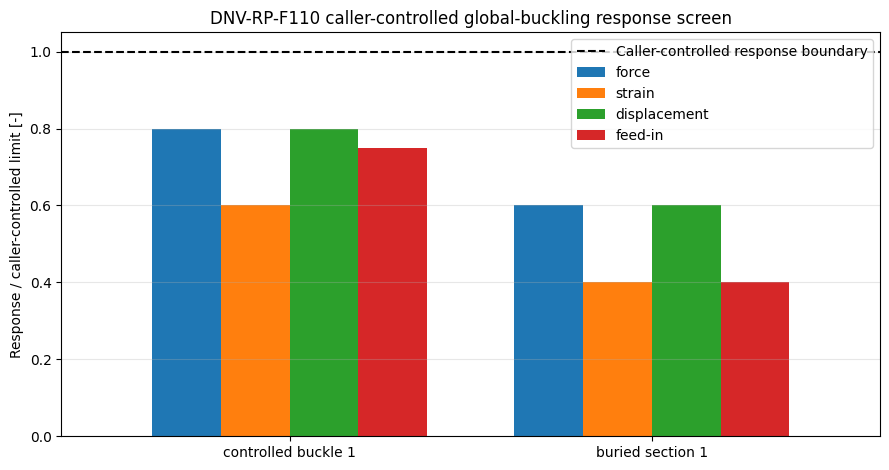

,distance [km],force,strain,displacement,feed-in
case,,,,,
controlled buckle 1,0.0,0.8,0.6,0.8,0.75
buried section 1,25.0,0.6,0.4,0.6,0.40


In [3]:
rows = [{
    'case': str(item.getLabel()),
    'distance [km]': float(item.getDistanceM()) / 1000.0,
    'force': float(item.getCompressiveForceUtilization()),
    'strain': float(item.getLongitudinalStrainUtilization()),
    'displacement': float(item.getGlobalDisplacementUtilization()),
    'feed-in': float(item.getFeedInLengthUtilization()),
} for item in assessment.getBucklingCases()]
table = pd.DataFrame(rows).set_index('case')

ax = table[['force', 'strain', 'displacement', 'feed-in']].plot.bar(figsize=(9, 4.8), width=0.76)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Caller-controlled response boundary')
ax.set_ylabel('Response / caller-controlled limit [-]')
ax.set_xlabel('')
ax.set_title('DNV-RP-F110 caller-controlled global-buckling response screen')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
assert (table[['force', 'strain', 'displacement', 'feed-in']] <= 1.0).all().all()
plt.show()
table

**Figure discussion.** The exposed controlled-buckling demonstration case has the governing force and displacement utilizations of 0.8, while feed-in utilization is 0.75. This does not establish acceptance: verify the structural model, response extraction, limit derivation, load combinations, uncertainty, and adjacent-standard interfaces.

<p><strong>Figure alt text:</strong> Grouped bar chart of caller-controlled force, strain, global-displacement, and feed-in response-to-limit utilization for one generic exposed controlled-buckling case and one generic buried buckling-prevention case, with a dashed boundary at utilization one.</p>

## 3. An exceeded response limit remains visible

A verified external case with peak strain above the supplied limit is still calculated. This separates evidence readiness from the engineering finding.

In [4]:
exceeded_cases = [
    ('controlled buckle 1', 0.0, 'operation', Configuration.EXPOSED, Strategy.CONTROLLED_BUCKLING, 8.0e6, 10.0e6, 0.012, 0.010, 4.0, 5.0, 75.0, 100.0),
]
exceeded = run_screen(cases=exceeded_cases)
exceeded_assessment = exceeded.getValue()
exceeded_case = exceeded_assessment.getBucklingCases().get(0)
finding = pd.Series({
    'status': str(exceeded.getStatus()),
    'longitudinal-strain margin [-]': float(exceeded_case.getLongitudinalStrainMarginFraction()),
    'maximum longitudinal-strain utilization [-]': float(exceeded_assessment.getMaximumLongitudinalStrainUtilization()),
    'all caller-controlled constraints satisfied': bool(exceeded_assessment.allConstraintsSatisfied()),
    'interpretation': 'Calculated screening finding; project review and action required',
})
assert str(exceeded.getStatus()) == 'CALCULATED_REVIEW_REQUIRED'
assert abs(float(exceeded_case.getLongitudinalStrainMarginFraction()) + 0.002) < 1e-12
assert not bool(exceeded_assessment.allConstraintsSatisfied())
finding.to_frame('exceeded case')

,exceeded case
status,CALCULATED_REVIEW_REQUIRED
longitudinal-strain margin [-],-0.002
maximum longitudinal-strain utilization [-],1.2
all caller-controlled constraints satisfied,False
interpretation,Calculated screening finding; project review a...


## 4. Fail closed when structural-model evidence is missing

Numeric response values are not self-validating. The same values are blocked when the global-structural-model evidence flag is false. Retain model scope, mesh and formulation, boundary conditions, pipe-soil basis, imperfections, load cases, validation, sensitivities, and accountable review beside the screen.

In [5]:
blocked = run_screen(structural_model_evidence=False)
findings = pd.DataFrame([{
    'code': str(item.toMap().get('code')),
    'severity': 'BLOCKER',
    'message': str(item.toMap().get('message')),
} for item in blocked.getReadiness().getBlockers()])
assert str(blocked.getStatus()) == 'BLOCKED'
assert blocked.getValue() is None
assert 'DNV_RP_F110_GLOBAL_MODEL_NOT_VERIFIED' in set(findings['code'])
findings

,code,severity,message
0,DNV_RP_F110_GLOBAL_MODEL_NOT_VERIFIED,BLOCKER,The global structural model and response extra...
